In [1]:
# ============================================================
# Nested-CV Ridge Regression to Predict Microbiome Features (Y)
# from Lifestyle/Metadata Features (X), with NO leakage
#
# 1) TRUE nested CV: outer CV evaluates; inner CV tunes alpha
# 2) No pre-CV imputation: SimpleImputer inside Pipeline
# 3) Optionally prevents subject leakage: GroupKFold if you have a subject_id
# 4) Stores outer-fold R2 mean/std and alpha distribution
# 5) Clean plots (no clamping of negative R2; scatter uses identity line)
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm  # use tqdm if not in notebook

from sklearn.model_selection import KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import joblib
import json
from pathlib import Path
from joblib import Parallel, delayed

# 1. Configuration
otu_file_path = "./Data/Cleaned_data/AGP_Otu_Data.csv"
metadata_file_path = "./Data/Cleaned_data/processed_metadata.csv"

metadata_index_col = "sample_name"
otu_index_col = 0

output_dir = "./hongrui_result/Ridge_NestedCV_Results/"
os.makedirs(output_dir, exist_ok=True)

n_cpu = -1

# Hard-coded exclusion list (high missingness in UKB)
EXCLUDE_METADATA_COLS = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    "artificial_sweeteners",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
]

# CV config
n_splits_outer = 5
n_splits_inner = 5
random_state_cv = 42

# OTU filter config (based on mean relative abundance)
abundance_threshold = 0.0001

# Ridge hyper-parameter grid
alphas_to_test = np.logspace(-3, 3, 7)  # 0.001 ... 1000
print(f"Alphas to test: {alphas_to_test}")

subject_id_col = None  # make sure each participant only has one sample, otherwise change this

# Target transformation choice
use_log1p_counts = True   # True => log1p(counts), False => log1p(relative abundance)
# note that the OTU table is counts, which added up to 10000

# 2. Load and Prepare Data
print("--- Loading data ---")
metadata_df = pd.read_csv(metadata_file_path, index_col=metadata_index_col)
otu_df = pd.read_csv(otu_file_path, index_col=otu_index_col)

# Align samples
common_samples = metadata_df.index.intersection(otu_df.index)
metadata_df = metadata_df.loc[common_samples].copy()
otu_df = otu_df.loc[common_samples].copy()
print(f"Data aligned. Found {len(common_samples)} common samples.")
print(f"Initial number of OTUs: {otu_df.shape[1]}")

# ------------------------------------------------------------
# 2.5 Taxa-map rename ONLY (NO collapse; preserves results)
# md5 OTU -> Family_Genus__<md5prefix> (unique), else Unmapped__<md5prefix>
# ------------------------------------------------------------
from pathlib import Path

taxa_map_path = Path("./Data/Raw_Data/taxa_md5.xls")  # TSV despite .xls

taxa_df = pd.read_csv(
    taxa_map_path,
    sep="\t",
    header=0,
    index_col=0,
    engine="python"
)

# Clean index + build Family_Genus
taxa_df.index = taxa_df.index.astype(str).str.strip()
taxa_df["Family"] = taxa_df["Family"].fillna("UnclassifiedFamily").astype(str).str.strip()
taxa_df["Genus"]  = taxa_df["Genus"].fillna("UnclassifiedGenus").astype(str).str.strip()
taxa_df["Family_Genus"] = taxa_df["Family"] + "_" + taxa_df["Genus"]

mapper = taxa_df["Family_Genus"].to_dict()

md5_prefix_len = 8  # 6–8 is usually safe

def make_unique(names):
    counts = {}
    out = []
    for n in names:
        k = counts.get(n, 0) + 1
        counts[n] = k
        out.append(n if k == 1 else f"{n}__{k}")
    return out

otu_md5 = otu_df.columns.astype(str).str.strip()

# Rename each OTU (1-to-1): Family_Genus__<md5prefix>, fallback Unmapped__<md5prefix>
new_cols = [
    f"{mapper.get(m, 'Unmapped')}__{m[:md5_prefix_len]}"
    for m in otu_md5
]

otu_df = otu_df.copy()
otu_df.columns = make_unique(new_cols)

n_mapped = sum(mapper.get(m, None) is not None for m in otu_md5)
print(f"[taxa-map] Mapped {n_mapped}/{len(otu_md5)} OTUs (rename-only; no collapse).")
print("Example renamed columns:", list(otu_df.columns[:5]))
print("Any duplicates after rename?", pd.Index(otu_df.columns).duplicated().any())

# Filter OTUs by mean relative abundance
otu_rel_abund = otu_df.div(otu_df.sum(axis=1), axis=0)
mean_rel_abund = otu_rel_abund.mean(axis=0)
otus_to_keep = mean_rel_abund[mean_rel_abund > abundance_threshold].index
otu_df_filtered = otu_df[otus_to_keep].copy()
print(f"Number of OTUs after filtering: {otu_df_filtered.shape[1]}")

# Define Y matrix
if use_log1p_counts:
    Y = np.log1p(otu_df_filtered)
    print("Using Y = log1p(counts).")
else:
    otu_rel_abund_filt = otu_df_filtered.div(otu_df_filtered.sum(axis=1), axis=0)
    Y = np.log1p(otu_rel_abund_filt)
    print("Using Y = log1p(relative abundance).")

# Define X matrix (numeric only)
numeric_cols_all = metadata_df.select_dtypes(include=np.number).columns.tolist()

excluded_present = [c for c in EXCLUDE_METADATA_COLS if c in numeric_cols_all]
numeric_cols = [c for c in numeric_cols_all if c not in set(EXCLUDE_METADATA_COLS)]

if excluded_present:
    print(
        f"Excluding {len(excluded_present)} metadata cols from X (to reduce UKB missingness): "
        f"{excluded_present}"
    )

X = metadata_df[numeric_cols].copy()
print(f"Using {X.shape[1]} numeric metadata features as predictors.")

# Groups (optional)
groups = None
if subject_id_col is not None:
    if subject_id_col not in metadata_df.columns:
        raise ValueError(
            f"subject_id_col='{subject_id_col}' not found in metadata_df columns. "
            f"Available cols include: {list(metadata_df.columns)[:20]} ..."
        )
    groups = metadata_df[subject_id_col].values
    print(f"Using GroupKFold with groups from column: {subject_id_col}")

# 3. Helpers
def make_pipeline(alpha: float) -> Pipeline:
    """Pipeline that avoids leakage: impute + scale + ridge."""
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

def get_cv_splitter(n_splits: int, use_groups: bool):
    """Return KFold or GroupKFold splitter."""
    if use_groups:
        return GroupKFold(n_splits=n_splits)
    return KFold(n_splits=n_splits, shuffle=True, random_state=random_state_cv)

from joblib import Parallel, delayed

def process_single_otu(otu_name, X, Y, alphas_to_test, n_splits_outer, n_splits_inner, groups=None):
    y = Y[otu_name].astype(float)
    
    if np.nanvar(y.values) < 1e-9:
        return {
            "OTU": otu_name, "outer_r2_mean": np.nan, "outer_r2_std": np.nan,
            "outer_r2_median": np.nan, "outer_best_alpha_mode": np.nan,
            "outer_best_alpha_mean": np.nan, # Added
            "n_samples": len(y), "last_fold_data": None
        }

    use_groups = groups is not None
    outer_splitter = get_cv_splitter(n_splits_outer, use_groups)
    inner_splitter = get_cv_splitter(n_splits_inner, use_groups)

    outer_r2_scores = []
    outer_best_alphas = []
    
    # We'll store the last fold data to reconstruct the scatter plot later
    last_fold_data = {}

    # Standard Outer Loop logic...
    outer_splits = list(outer_splitter.split(X, y, groups=groups)) if use_groups else list(outer_splitter.split(X, y))
    
    for ofold, (tr_idx, te_idx) in enumerate(outer_splits):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # Inner CV to find best alpha
        best_alpha = None
        best_inner_score = -np.inf
        inner_splits = list(inner_splitter.split(X_tr, y_tr, groups=groups[tr_idx] if use_groups else None))
        
        for alpha in alphas_to_test:
            inner_scores = [r2_score(y_tr.iloc[iva_idx], 
                            make_pipeline(alpha).fit(X_tr.iloc[itr_idx], y_tr.iloc[itr_idx]).predict(X_tr.iloc[iva_idx])) 
                            for itr_idx, iva_idx in inner_splits]
            
            inner_mean = np.mean(inner_scores)
            if inner_mean > best_inner_score:
                best_inner_score = inner_mean
                best_alpha = alpha

        # Final fit for this outer fold
        pipe = make_pipeline(best_alpha).fit(X_tr, y_tr)
        pred_te = pipe.predict(X_te)
        outer_r2_scores.append(r2_score(y_te, pred_te))
        outer_best_alphas.append(best_alpha)
        
        # Save last fold for the scatter plot
        if ofold == len(outer_splits) - 1:
            last_fold_data = {"y_true": y_te.values, "y_pred": pred_te, "alpha": best_alpha}

# Calculate the full set of stats
    r2_mean = np.mean(outer_r2_scores)
    r2_std = np.std(outer_r2_scores, ddof=1)
    r2_median = np.median(outer_r2_scores) # Added
    
    unique_alphas, counts = np.unique(outer_best_alphas, return_counts=True)
    alpha_mode = unique_alphas[np.argmax(counts)]
    alpha_mean = np.mean(outer_best_alphas) # Added
    
    return {
        "OTU": otu_name,
        "outer_r2_mean": float(r2_mean),
        "outer_r2_std": float(r2_std),
        "outer_r2_median": float(r2_median), # Added
        "outer_best_alpha_mode": float(alpha_mode),
        "outer_best_alpha_mean": float(alpha_mean), # Added
        "n_samples": len(y),
        "last_fold_data": last_fold_data 
    }

# 4. Nested CV per OTU
print(f"\n--- Running Nested CV (outer={n_splits_outer}, inner={n_splits_inner}) ---")
use_groups = groups is not None

print(f"Starting parallel processing with {n_cpu} CPUs...")

# 1. RUN PARALLEL LOGIC
# This captures all the dictionaries returned by process_single_otu into a list
results_list = Parallel(n_jobs=n_cpu)(
    delayed(process_single_otu)(
        otu, X, Y, alphas_to_test, n_splits_outer, n_splits_inner, groups
    ) for otu in tqdm(Y.columns, desc="Processing OTUs")
)

# 2. CONVERT TO DATAFRAME (The critical fix)
results_df = pd.DataFrame(results_list)

# 3. POST-PROCESS BEST SCATTER DATA
# We find the index of the OTU with the highest mean R2
best_idx = results_df['outer_r2_mean'].idxmax()
best_otu_info = results_list[best_idx]

best_scatter = {
    "otu": best_otu_info["OTU"],
    "y_true": pd.Series(best_otu_info["last_fold_data"]["y_true"]),
    "y_pred": best_otu_info["last_fold_data"]["y_pred"],
    "r2": r2_score(best_otu_info["last_fold_data"]["y_true"], best_otu_info["last_fold_data"]["y_pred"]),
    "alpha": best_otu_info["last_fold_data"]["alpha"],
    "outer_mean_r2": best_otu_info["outer_r2_mean"]
}

# 4. SAVE RESULTS
results_csv_path = os.path.join(output_dir, "nestedcv_ridge_all_otus_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"\nSaved full results to: {results_csv_path}")

# 5. Rank and show Top 10
print("\n--- Top 10 OTUs by OUTER-CV mean R^2 (proper nested CV) ---")
ranked = results_df.dropna(subset=["outer_r2_mean"]).sort_values("outer_r2_mean", ascending=False)
print(ranked[["OTU", "outer_r2_mean", "outer_r2_std", "outer_best_alpha_mode"]].head(10).to_string(index=False))

top10_df = ranked.head(10).copy()

Alphas to test: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
--- Loading data ---
Data aligned. Found 9559 common samples.
Initial number of OTUs: 4460
[taxa-map] Mapped 4460/4460 OTUs (rename-only; no collapse).
Example renamed columns: ['Bacteroidaceae_Bacteroides__ef63210b', 'Bacteroidaceae_Bacteroides__fee9d92e', 'Ruminococcaceae_Faecalibacterium__26beb329', 'Bacteroidaceae_Bacteroides__48645283', 'Ruminococcaceae_Faecalibacterium__6bfe71f5']
Any duplicates after rename? False
Number of OTUs after filtering: 819
Using Y = log1p(counts).
Excluding 15 metadata cols from X (to reduce UKB missingness): ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams', 'sugar_sweetened_drink_frequency', 'artificial_sweeteners', 'olive_oil', 'prepared_meals_frequency', 'ready_to_eat_meals_frequency']
Using 29 numeric metadata features as pred

Processing OTUs:   0%|          | 0/819 [00:00<?, ?it/s]


Saved full results to: ./hongrui_result/Ridge_NestedCV_Results/nestedcv_ridge_all_otus_results.csv

--- Top 10 OTUs by OUTER-CV mean R^2 (proper nested CV) ---
                                                        OTU  outer_r2_mean  outer_r2_std  outer_best_alpha_mode
               Bifidobacteriaceae_Bifidobacterium__a5d26678       0.095838      0.006163                  100.0
          Ruminococcaceae_Ruminococcaceae_UCG-002__b4b6efb2       0.074684      0.015199                  100.0
Christensenellaceae_Christensenellaceae_R-7_group__51c02d84       0.071459      0.011458                  100.0
                    Ruminococcaceae_Oscillibacter__5a9c4686       0.063951      0.007361                  100.0
          Ruminococcaceae_Ruminococcaceae_UCG-002__e8d0041a       0.063090      0.007743                  100.0
    Ruminococcaceae_Ruminococcaceae_NK4A214_group__760c2f19       0.062316      0.010469                  100.0
          Ruminococcaceae_Ruminococcaceae_UCG-005__849f

In [2]:
# ============================================================
# 5b. Plot original vs log1p distributions for top predicted OTUs
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages

dist_dir = os.path.join(output_dir, "top_otu_distributions")
os.makedirs(dist_dir, exist_ok=True)

top_n_for_dist = 10   # same as top10_df; change if you want fewer/more
top_dist_df = ranked.head(top_n_for_dist).copy()

dist_pdf_path = os.path.join(dist_dir, f"top{top_n_for_dist}_otu_original_vs_log1p_distributions.pdf")

def safe_filename(x):
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(x))[:150]

with PdfPages(dist_pdf_path) as pdf:
    for i, row in enumerate(top_dist_df.itertuples(index=False), start=1):
        otu = row.OTU

        # Original raw counts
        y_raw = otu_df_filtered[otu].astype(float)

        # Log(x + 1) transform
        y_log = np.log1p(y_raw)

        zero_frac = (y_raw == 0).mean()
        r2_mean = float(row.outer_r2_mean)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Left: original distribution
        axes[0].hist(y_raw, bins=50, edgecolor="black", alpha=0.7)
        axes[0].set_title(f"Original distribution\n{otu}")
        axes[0].set_xlabel("Raw OTU count")
        axes[0].set_ylabel("Frequency")
        axes[0].grid(True, linestyle="--", alpha=0.4)

        # Right: log1p distribution
        axes[1].hist(y_log, bins=50, edgecolor="black", alpha=0.7)
        axes[1].set_title(f"log1p distribution\n{otu}")
        axes[1].set_xlabel("log(count + 1)")
        axes[1].set_ylabel("Frequency")
        axes[1].grid(True, linestyle="--", alpha=0.4)

        # Overall page title
        fig.suptitle(
            f"#{i} Top predicted OTU: {otu}\n"
            f"Outer-CV mean R² = {r2_mean:.3f} | "
            f"Mean raw count = {y_raw.mean():.3f} | "
            f"Median raw count = {y_raw.median():.3f} | "
            f"Zero fraction = {zero_frac:.3f}",
            fontsize=13
        )

        plt.tight_layout(rect=[0, 0, 1, 0.92])

        # Save one page into PDF
        pdf.savefig(fig)

        # Also save individual PNG
        png_path = os.path.join(
            dist_dir,
            f"top{i:02d}_{safe_filename(otu)}_original_vs_log1p.png"
        )
        fig.savefig(png_path, dpi=300)

        plt.close(fig)

print(f"[SAVED] Distribution PDF: {dist_pdf_path}")
print(f"[SAVED] Individual distribution PNGs in: {dist_dir}")

[SAVED] Distribution PDF: ./hongrui_result/Ridge_NestedCV_Results/top_otu_distributions/top10_otu_original_vs_log1p_distributions.pdf
[SAVED] Individual distribution PNGs in: ./hongrui_result/Ridge_NestedCV_Results/top_otu_distributions


In [3]:
# 6. Plots
print("\n--- Generating Plots ---")

# Plot 1: Top 10 bar plot with error bars (std across OUTER folds)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="outer_r2_mean",
    y="OTU",
    data=top10_df,
    orient="h",
    palette="viridis",
)
ax.errorbar(
    x=top10_df["outer_r2_mean"].values,
    y=np.arange(len(top10_df)),
    xerr=top10_df["outer_r2_std"].values,
    fmt="none",
    capsize=5
)
plt.title("Top 10 OTUs Predictable from Metadata (Nested CV Outer-Fold R²)")
plt.xlabel("Outer-CV Mean R² (± SD across outer folds)")
plt.ylabel("OTU")
# don't hide negatives; set left bound to min(0, min)
xmin = float(min(0.0, top10_df["outer_r2_mean"].min() - top10_df["outer_r2_std"].max()))
plt.xlim(left=xmin)
plt.tight_layout()
barplot_path = os.path.join(output_dir, "top10_nestedcv_outer_r2_barplot.pdf")
plt.savefig(barplot_path)
plt.close()
print(f"Saved: {barplot_path}")

# Plot 2: Scatter for best OTU (last outer fold), with identity line
if best_scatter["otu"] is not None:
    otu_name = best_scatter["otu"]
    y_true = best_scatter["y_true"].astype(float)
    y_pred = np.array(best_scatter["y_pred"], dtype=float)
    r2_last = float(best_scatter["r2"])
    alpha_last = float(best_scatter["alpha"])
    outer_mean = float(best_scatter["outer_mean_r2"])

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.5, label="Outer-fold predictions")

    # Identity line
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi], "--", linewidth=2, label="Identity (y = x)")

    plt.title(f"Best OTU: {otu_name}\nLast Outer Fold (alpha={alpha_last:g})")
    plt.xlabel("True Y")
    plt.ylabel("Predicted Y")
    plt.text(
        0.05, 0.95,
        f"Last-fold R² = {r2_last:.3f}\nOuter mean R² = {outer_mean:.3f}",
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.5)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    scatter_path = os.path.join(output_dir, "best_otu_last_outerfold_scatter.pdf")
    plt.savefig(scatter_path)
    plt.close()
    print(f"Saved: {scatter_path}")
else:
    print("No OTU available for scatter plot.")

print("\nAnalysis complete.")

# ============================================================
# Notes / Optional upgrades:
# - If you have repeated samples per person, set subject_id_col to a valid column
#   in metadata_df and GroupKFold will prevent leakage.
# - Consider compositional transforms (CLR) instead of log1p(counts).
# - If you keep counts, consider including log(library size) in X to control depth.
# ============================================================

# ============================================================
# 6b) FEATURE IMPORTANCE for Top-10 OTU models (by outer_r2_mean)
#     Importance = standardized Ridge coefficients (because of StandardScaler)
#     Output: 1 multi-page PDF + per-OTU PNGs
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages

TOP_FEATS = 25  # top features (by |coef|) per OTU to show

fi_dir = os.path.join(output_dir, "top10_feature_importance")
os.makedirs(fi_dir, exist_ok=True)

pdf_path = os.path.join(fi_dir, "top10_otu_feature_importance.pdf")

# Safety: ensure we have the columns we need
need_cols = {"OTU", "outer_r2_mean", "outer_best_alpha_mode"}
missing = need_cols - set(top10_df.columns)
if missing:
    raise ValueError(f"top10_df missing required columns: {missing}. Available: {list(top10_df.columns)}")

with PdfPages(pdf_path) as pdf:
    for i, row in enumerate(top10_df.itertuples(index=False), start=1):
        otu = row.OTU
        r2m = float(row.outer_r2_mean)
        alpha = row.outer_best_alpha_mode
        if pd.isna(alpha):
            alpha = float(np.median(alphas_to_test))
        else:
            alpha = float(alpha)

        # Fit final model on ALL data for this OTU (same approach as your "deployment" fits)
        y_all = Y[otu].astype(float).values
        pipe = make_pipeline(alpha).fit(X, y_all)

        # Coefs correspond to standardized predictors (because scaler is in the pipeline)
        coef = pd.Series(pipe.named_steps["ridge"].coef_, index=X.columns)

        # Top |coef|
        imp = coef.abs().sort_values(ascending=False).head(TOP_FEATS)
        coef_top = coef.reindex(imp.index)  # keep signed values

        # Plot
        plt.figure(figsize=(10, max(5, 0.35 * len(coef_top) + 2)))
        y_pos = np.arange(len(coef_top))[::-1]
        plt.barh(y_pos, coef_top.values[::-1])
        plt.yticks(y_pos, coef_top.index[::-1])
        plt.axvline(0.0, color="gray", linewidth=1.5)
        plt.xlabel("Standardized Ridge coefficient")
        plt.title(f"#{i} OTU: {otu}\nOuter-CV mean R²={r2m:.3f} | alpha={alpha:g} | Top {TOP_FEATS} features")
        plt.tight_layout()

        # Save per-OTU PNG + add to PDF
        png_path = os.path.join(fi_dir, f"top10_{i:02d}_{otu}_feature_importance.png")
        plt.savefig(png_path, dpi=300)
        pdf.savefig()  # adds current figure as a new PDF page
        plt.close()

print(f"[SAVED] {pdf_path}")
print(f"[SAVED] Per-OTU PNGs in: {fi_dir}")


--- Generating Plots ---
Saved: ./hongrui_result/Ridge_NestedCV_Results/top10_nestedcv_outer_r2_barplot.pdf


/tmp/ipykernel_2108405/2790282837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved: ./hongrui_result/Ridge_NestedCV_Results/best_otu_last_outerfold_scatter.pdf

Analysis complete.
[SAVED] ./hongrui_result/Ridge_NestedCV_Results/top10_feature_importance/top10_otu_feature_importance.pdf
[SAVED] Per-OTU PNGs in: ./hongrui_result/Ridge_NestedCV_Results/top10_feature_importance


In [4]:
# ============================================================
# 7. SAVE "DEPLOYMENT" RIDGE MODELS for OTUs with R2 > threshold
#    - Uses alpha chosen from nested-CV summary (outer_best_alpha_mode)
#    - Fits pipeline on ALL AGP samples (X, y) for each selected OTU
#    - Saves:
#        ridge_otu_models.pkl          (dict: OTU -> fitted sklearn Pipeline)
#        ridge_training_metadata.json  (train columns, transform settings, otus saved, alpha, CV stats)
# ============================================================

r2_save_threshold = 0.04
model_dir = Path("./Ridge_OTU_Trained_Models/")
model_dir.mkdir(parents=True, exist_ok=True)

# Select OTUs to save
save_df = results_df.dropna(subset=["outer_r2_mean"]).copy()
save_df = save_df[save_df["outer_r2_mean"] > r2_save_threshold].copy()
save_df = save_df.sort_values("outer_r2_mean", ascending=False)

print(f"\n--- Saving OTU Ridge models with outer_r2_mean > {r2_save_threshold} ---")
print(f"OTUs eligible for saving: {save_df.shape[0]}")

# Fit final models on ALL data for those OTUs
ridge_models = {}        # OTU -> fitted pipeline
ridge_model_info = {}    # OTU -> alpha + nested-CV summary

for row in tqdm(save_df.itertuples(index=False), total=save_df.shape[0], desc="Fitting final ridge models"):
    otu = row.OTU
    alpha = row.outer_best_alpha_mode
    if pd.isna(alpha):
        # fallback if something weird happened
        alpha = float(np.median(alphas_to_test))
    else:
        alpha = float(alpha)

    y_all = Y[otu].astype(float).values
    pipe = make_pipeline(alpha)
    pipe.fit(X, y_all)

    ridge_models[otu] = pipe
    ridge_model_info[otu] = {
        "alpha": alpha,
        "outer_r2_mean": float(row.outer_r2_mean),
        "outer_r2_std": float(row.outer_r2_std),
        "outer_r2_median": float(row.outer_r2_median),
        "outer_best_alpha_mode": float(row.outer_best_alpha_mode) if not pd.isna(row.outer_best_alpha_mode) else None,
        "outer_best_alpha_mean": float(row.outer_best_alpha_mean) if not pd.isna(row.outer_best_alpha_mean) else None,
    }

# Save models
models_path = model_dir / "ridge_otu_models.pkl"
joblib.dump(ridge_models, models_path)
print(f"Saved {len(ridge_models)} ridge OTU models to: {models_path}")

# Save training metadata (for UKB projection)
train_meta = {
    "r2_save_threshold": r2_save_threshold,
    "abundance_threshold": float(abundance_threshold),
    "use_log1p_counts": bool(use_log1p_counts),
    "alphas_to_test": [float(a) for a in alphas_to_test],
    "train_cols": list(X.columns),                 # numeric metadata used as X
    "saved_otus": list(save_df["OTU"].values),     # OTU targets saved
    "ridge_model_info": ridge_model_info,
    "n_train_samples": int(X.shape[0]),
    "excluded_metadata_cols": list(EXCLUDE_METADATA_COLS),
}

# Optional: record which OTUs survived abundance filtering (if you want traceability)
try:
    train_meta["otus_kept_after_filter"] = list(otu_df_filtered.columns)
except Exception:
    pass

meta_path = model_dir / "ridge_training_metadata.json"
with open(meta_path, "w") as f:
    json.dump(train_meta, f, indent=2)
print(f"Saved training metadata to: {meta_path}")

# Also save a human-readable list
save_df_path = model_dir / "saved_otus_r2_gt_threshold.csv"
save_df.to_csv(save_df_path, index=False)
print(f"Saved OTU save-list to: {save_df_path}")

print("\nDeployment model saving complete.")


--- Saving OTU Ridge models with outer_r2_mean > 0.04 ---
OTUs eligible for saving: 32


Fitting final ridge models:   0%|          | 0/32 [00:00<?, ?it/s]

Saved 32 ridge OTU models to: Ridge_OTU_Trained_Models/ridge_otu_models.pkl
Saved training metadata to: Ridge_OTU_Trained_Models/ridge_training_metadata.json
Saved OTU save-list to: Ridge_OTU_Trained_Models/saved_otus_r2_gt_threshold.csv

Deployment model saving complete.


Saved: ./hongrui_result/Ridge_NestedCV_Results/otu_count_vs_r2_threshold.pdf


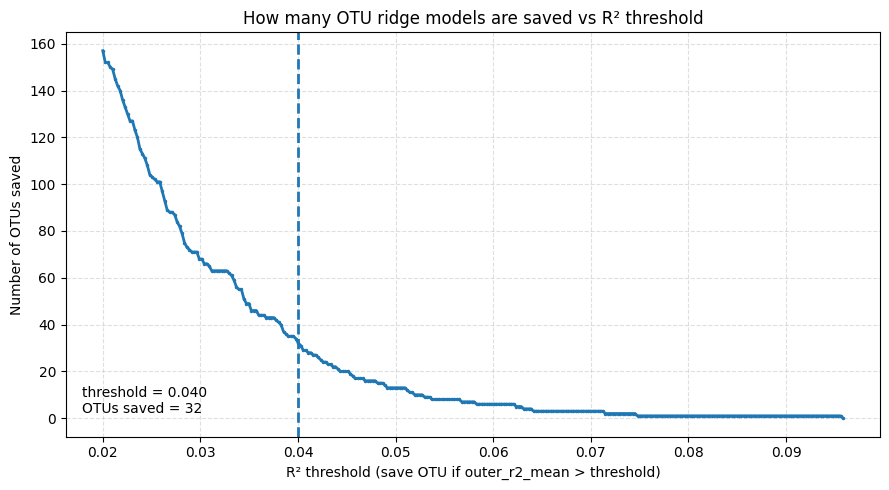

In [5]:
# ============================================================
# Plot: number of OTUs saved vs R² threshold
#   x = R² threshold (small -> large)
#   y = count of OTUs with outer_r2_mean > threshold
# ============================================================

r2_vals = results_df["outer_r2_mean"].dropna().astype(float).values
r2_vals = r2_vals[np.isfinite(r2_vals)]

if r2_vals.size == 0:
    print("No valid outer_r2_mean values found; skipping threshold curve plot.")
else:
    r2_sorted = np.sort(r2_vals)
    n = r2_sorted.size

    # Threshold grid (covers the full observed range; includes 0 if you want it)
    x_min = float(max(0.02, r2_sorted.min()))
    x_max = float(r2_sorted.max())
    thresholds = np.linspace(x_min, x_max, 300)

    # Count of OTUs with R² > threshold, efficiently via searchsorted on sorted array
    # idx = number of values <= threshold  => count(> threshold) = n - idx
    idx = np.searchsorted(r2_sorted, thresholds, side="right")
    n_saved = n - idx

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, n_saved, marker=".", markersize=3, linewidth=2)
    plt.title("How many OTU ridge models are saved vs R² threshold")
    plt.xlabel("R² threshold (save OTU if outer_r2_mean > threshold)")
    plt.ylabel("Number of OTUs saved")
    plt.grid(True, linestyle="--", alpha=0.4)

    # Optional: show your current chosen threshold on the curve
    if "r2_save_threshold" in globals():
        t = float(r2_save_threshold)
        saved_at_t = int((r2_vals > t).sum())
        plt.axvline(t, linestyle="--", linewidth=2)
        plt.text(
            0.02, 0.05,
            f"threshold = {t:.3f}\nOTUs saved = {saved_at_t}",
            transform=plt.gca().transAxes,
            va="bottom"
        )

    plt.tight_layout()
    curve_path = os.path.join(output_dir, "otu_count_vs_r2_threshold.pdf")
    plt.savefig(curve_path)
    print(f"Saved: {curve_path}")